
# PowerCast — EDA Notebook
Exploring the relationship between weather and German electricity prices (2025).

In [ ]:

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

## Load Data
Loading the cleaned, merged dataset (weather + prices, hourly, full year 2025).

In [5]:
df = pd.read_csv("../data/processed/merged_2025.csv")
df["time"] = pd.to_datetime(df["time"])
print(df.shape)
print(df.head())

(8760, 5)
                 time  temperature_2m  wind_speed_10m  hour  price
0 2025-01-01 00:00:00             5.5            28.7     0   1.60
1 2025-01-01 01:00:00             5.9            29.0     1   0.00
2 2025-01-01 02:00:00             6.2            30.5     2  -0.01
3 2025-01-01 03:00:00             6.9            31.6     3  -0.01
4 2025-01-01 04:00:00             7.3            31.3     4  -0.06


## Correlation Check
How strongly do temperature and wind speed relate to price?
- Close to +1: both go up together
- Close to -1: one goes up, the other goes down
- Close to 0: no clear pattern

In [6]:
print(df[["temperature_2m", "wind_speed_10m", "price"]].corr())

                temperature_2m  wind_speed_10m     price
temperature_2m        1.000000        0.090290 -0.329668
wind_speed_10m        0.090290        1.000000 -0.392904
price                -0.329668       -0.392904  1.000000


## Scatter Plots
Each dot = one hour of the year (8,760 total).
Looking for: does the cloud trend downward as wind speed / temperature increases?

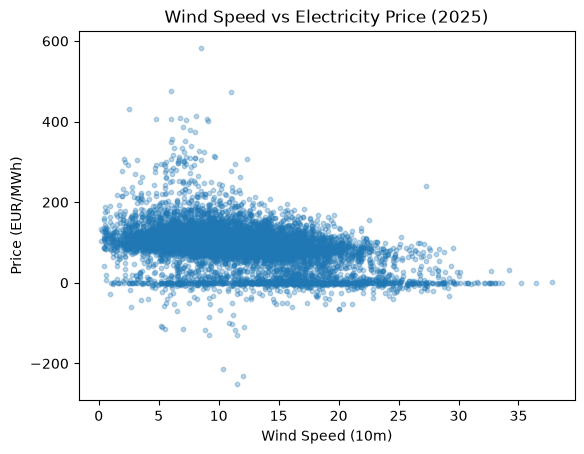

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df["wind_speed_10m"], df["price"], alpha=0.3, s=10)
plt.xlabel("Wind Speed (10m)")
plt.ylabel("Price (EUR/MWh)")
plt.title("Wind Speed vs Electricity Price (2025)")
plt.show()

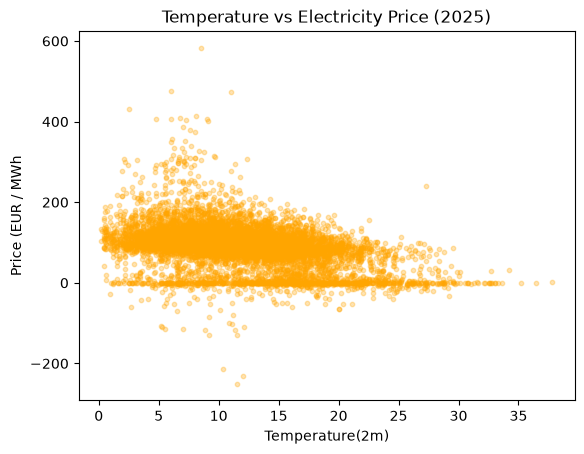

In [20]:
# Wind speed vs price scatter plot
plt.scatter(df["wind_speed_10m"], df["price"], alpha=0.3, s = 10, color="orange")
plt.xlabel("Temperature(2m)")
plt.ylabel("Price (EUR / MWh")

plt.title("Temperature vs Electricity Price (2025)")
plt.show()

## Price Extremes
What were the most expensive and cheapest hours in 2ß25, and what was the weather doing ? 

In [15]:
# Most expensive hour -- what was the weather at that moment ?

print("Highest price:", df["price"].max())
most_expensive = df[df["price"] == df["price"].max()]
print(most_expensive)

# Cheapest hour - same question
print("\n Lowest price:", df["price"].min())
cheapest = df[df["price"] == df["price"].min()]
print(cheapest)

Highest price: 583.4
                   time  temperature_2m  wind_speed_10m  hour  price  \
472 2025-01-20 16:00:00            -2.1             8.5    16  583.4   

          wind_bin       temp_bin  
472  (7.72, 11.48]  (-2.94, 1.22]  

 Lowest price: -250.32
                    time  temperature_2m  wind_speed_10m  hour   price  \
3131 2025-05-11 11:00:00            18.8            11.5    11 -250.32   

            wind_bin        temp_bin  
3131  (11.48, 15.24]  (17.86, 22.02]  


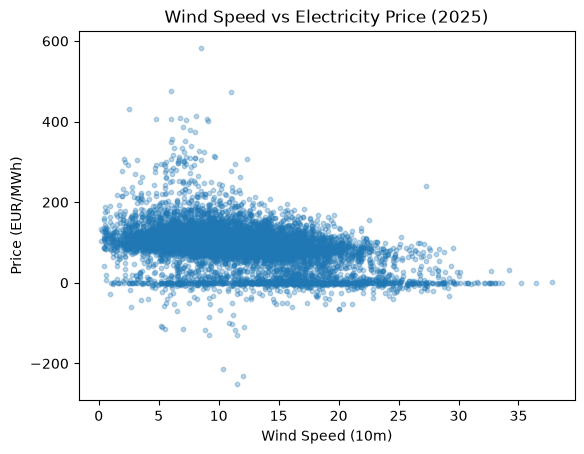

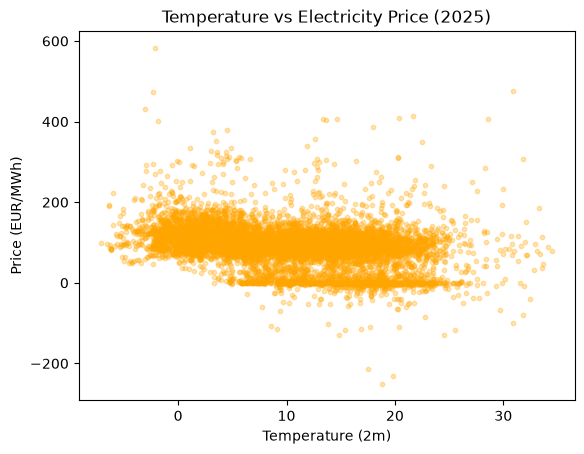

In [17]:
# save the wind speed chart

# Save wind speed chart
fig1, ax1 = plt.subplots()
ax1.scatter(df["wind_speed_10m"], df["price"], alpha=0.3, s=10)
ax1.set_xlabel("Wind Speed (10m)")
ax1.set_ylabel("Price (EUR/MWh)")
ax1.set_title("Wind Speed vs Electricity Price (2025)")
fig1.savefig("../outputs/figures/wind_vs_price.png")
plt.show()

# Save temperature chart
fig2, ax2 = plt.subplots()
ax2.scatter(df["temperature_2m"], df["price"], alpha=0.3, s=10, color="orange")
ax2.set_xlabel("Temperature (2m)")
ax2.set_ylabel("Price (EUR/MWh)")
ax2.set_title("Temperature vs Electricity Price (2025)")
fig2.savefig("../outputs/figures/temp_vs_price.png")
plt.show()

### Average Price by Hour of Day
Does electricity price follow a daily pattern? When are peak and off-peak hours?

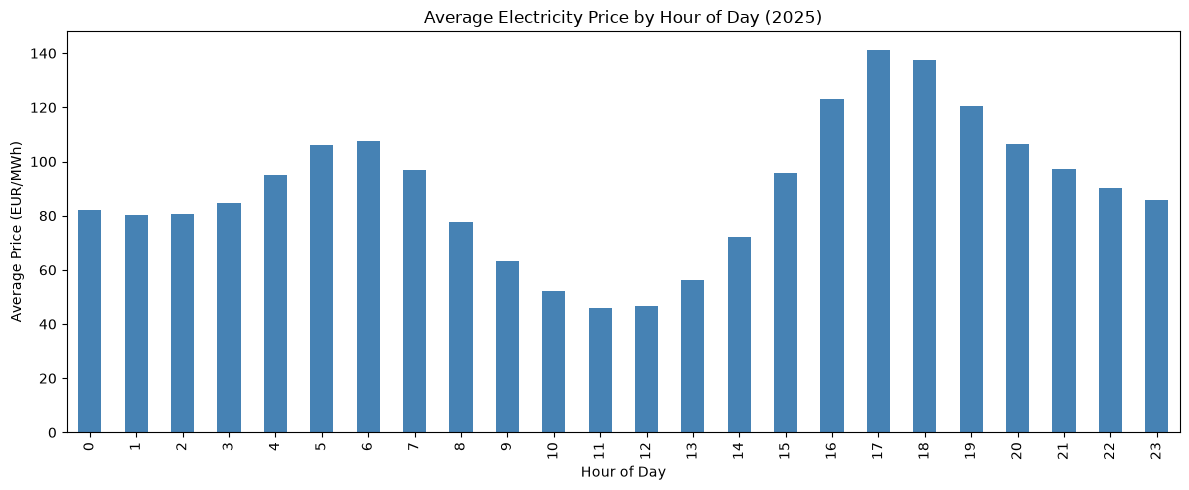

In [18]:
# Group all 8760 hours by their hour-of-day (0-23)
# Calculate the average price for each hour across the entire year
hourly_avg = df.groupby("hour")["price"].mean()

# Bar chart — one bar per hour of day
plt.figure(figsize=(12, 5))
hourly_avg.plot(kind="bar", color="steelblue")
plt.xlabel("Hour of Day")
plt.ylabel("Average Price (EUR/MWh)")
plt.title("Average Electricity Price by Hour of Day (2025)")
plt.tight_layout()
plt.show()


### Negative price Hours
Producers literally paying to give electricity away. How often does this happen, and when? 

Total hours with negative prices: 573
That's 6.5  % of the year


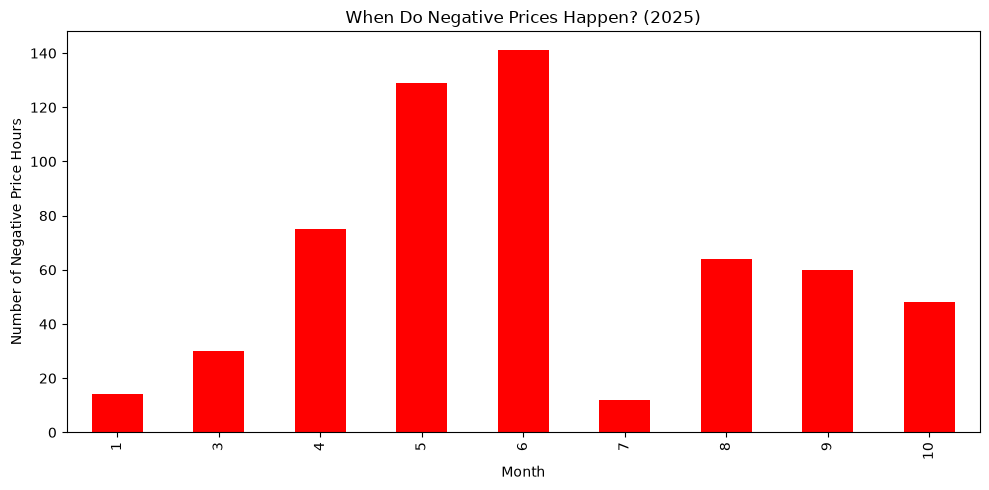

In [22]:
# How many hours in 2025 had the negative prices ? 
negative_hours = df[df["price"]<0]
print("Total hours with negative prices:", len(negative_hours))
print("That's", round(len(negative_hours)/len(df)* 100,1), " % of the year")

# Which month have the most negative price hours? 
negative_by_month = negative_hours.groupby(negative_hours["time"].dt.month).size()
plt.figure(figsize=(10,5))
negative_by_month.plot(kind = "bar", color="red")
plt.xlabel("Month")
plt.ylabel("Number of Negative Price Hours")
plt.title("When Do Negative Prices Happen? (2025)")
plt.tight_layout()
plt.show()